# Save IMERG rain rate & Matu filter 

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# (optional) Thread-cap + diagnostics are now in the next imports cell.
# Restart kernel, then run that imports cell only.


In [ ]:
# Cap OpenBLAS/OpenMP BEFORE numpy/scipy load (RLIMIT_NPROC soft=500 on this host)
import os, json, time, resource
_DBG = "/home1/datahome/ilarroch/.cursor/debug-a8cb97.log"

def _dbg(hid, msg, data, run_id="pre-fix"):
    with open(_DBG, "a") as f:
        f.write(json.dumps({
            "sessionId": "a8cb97", "runId": run_id, "hypothesisId": hid,
            "location": "save_IMERG_import", "message": msg,
            "data": data, "timestamp": int(time.time() * 1000),
        }) + "\n")

def _count_user_threads():
    uid, procs, threads = os.getuid(), 0, 0
    for name in os.listdir("/proc"):
        if not name.isdigit():
            continue
        try:
            with open(f"/proc/{name}/status") as s:
                txt = s.read()
            ul = [l for l in txt.splitlines() if l.startswith("Uid:")]
            if not ul or int(ul[0].split()[1]) != uid:
                continue
            procs += 1
            tl = [l for l in txt.splitlines() if l.startswith("Threads:")]
            if tl:
                threads += int(tl[0].split()[1])
        except Exception:
            pass
    return procs, threads

_soft, _hard = resource.getrlimit(resource.RLIMIT_NPROC)
_procs, _threads = _count_user_threads()
_dbg("A", "before_thread_cap", {
    "rlimit_soft": _soft, "user_processes": _procs, "user_threads": _threads,
    "headroom": _soft - _threads, "cpu_count": os.cpu_count(),
    "OPENBLAS": os.environ.get("OPENBLAS_NUM_THREADS"),
})
for _k in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_k] = "1"
_dbg("C", "after_thread_cap_env", {"OPENBLAS": os.environ["OPENBLAS_NUM_THREADS"], "headroom": _soft - _threads})

import glob
import numpy as np
import xarray as xr
import re
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import date, datetime, timedelta, timezone
from tqdm import tqdm
import pandas as pd
import sys
sys.path.append(os.path.abspath("/home1/datahome/ilarroch/data/INES/CODE/swot_rain_filter"))

_t0 = time.time()
try:
    import SWOT_tools as st
    import RAIN_tools as rt
    _procs2, _threads2 = _count_user_threads()
    _dbg("D", "import_ok", {
        "elapsed_s": round(time.time() - _t0, 3),
        "user_threads_after": _threads2,
        "headroom_after": _soft - _threads2,
    }, run_id="post-fix")
    print(f"imports OK in {time.time()-_t0:.1f}s; threads={_threads2}, headroom={_soft-_threads2}")
except Exception as _e:
    _dbg("D", "import_failed", {
        "error": type(_e).__name__, "repr": repr(_e),
        "elapsed_s": round(time.time() - _t0, 3),
    }, run_id="post-fix")
    raise


# **I] DATA**

## 1.1 Chargement des données SWOT

In [2]:
SWOT_ROOT_INES = "/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0"

swot_files = glob.glob(SWOT_ROOT_INES + "/*")
len(swot_files)

2315

## 1.2 Fonction pour récupérer le début et la fin d'un fichier SWOT 

In [3]:
_SWOT_FN_RE  = re.compile(r"_(\d{8}T\d{6})_(\d{8}T\d{6})_")
_SWOT_FN_FMT = "%Y%m%dT%H%M%S"


def parse_swot_filename_times(fname: str) -> tuple:
    """Extract (t_start, t_end) from a SWOT filename, or (None, None)."""
    m = _SWOT_FN_RE.search(fname)
    if not m:
        return None, None
    t0 = datetime.strptime(m.group(1), _SWOT_FN_FMT).replace(tzinfo=timezone.utc)
    t1 = datetime.strptime(m.group(2), _SWOT_FN_FMT).replace(tzinfo=timezone.utc)
    return t0, t1

# **II] Tests sur un fichier**

In [4]:
swot_file = swot_files[0]
print(swot_file)

/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0/SWOT_L2_LR_SSH_WindWave_030_203_20250324T123323_20250324T132451_PGD0_01.nc


In [5]:
t0, t1 = parse_swot_filename_times(swot_file)
print("Début: ", t0)
print("Fin: ", t1)

Début:  2025-03-24 12:33:23+00:00
Fin:  2025-03-24 13:24:51+00:00


In [6]:
pass_time_duration_in_sec = 6173.62/2 
pass_time_duration_in_min = int(pass_time_duration_in_sec // 60)
remaining_seconds = int(pass_time_duration_in_sec % 60)
print(f"Duration of a SWOT half-revolution, i.e. one pass: {pass_time_duration_in_min}min {remaining_seconds}sec")

Duration of a SWOT half-revolution, i.e. one pass: 51min 26sec


### Method explanation

We get t_mid, i.e. the time at which SWOT is half way of the current pass.  
t_start is the beginning and t_end the end.  
We then look for the closest IMERG file in time.    
IMERG time resolution is 30 minutes.  
A SWOT pass length in time is 51min 26sec.  
At worst, t_mid is 15 minutes delayed / in advance compared to the closet IMERG file.   
Therefore, at worst, t_start or t_end will be at 15 + (51min26sec/2) = 41min43s delayed / in advance compared to the closest IMERG file.  
This is considered as acceptable, as the purpose here is to define a large scale filter to get rid of large scale rain patches (mesoscale).  
They are stationnary enough at these timescales.   
This is obviously not necessarily the case for the fine scale.   

## Case study showing how it works

In [7]:
ds_swot = xr.open_dataset(swot_file)
ds_swot, t_start_str, t_end_str = st.quick_format_ds_swot(ds_swot)
lon_swot_min, lon_swot_max = np.nanmin(ds_swot.longitude.values), np.nanmax(ds_swot.longitude.values)
lat_swot_min, lat_swot_max = np.nanmin(ds_swot.latitude.values), np.nanmax(ds_swot.latitude.values)
area = [lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max]
print("Area covered by the current SWOT pass:\n", area)
print(f"Timespan: {t_start_str} --- {t_end_str}")
t_start, t_end = pd.to_datetime(t_start_str, format="%d/%m/%Y %H:%M:%S").replace(tzinfo=timezone.utc), pd.to_datetime(t_end_str, format="%d/%m/%Y %H:%M:%S").replace(tzinfo=timezone.utc)
t_mid   = t_start + (t_end - t_start) / 2
print("t_mid: ", t_mid.strftime(format="%d/%m/%Y %H:%M:%S"))

NameError: name 'st' is not defined

In [9]:
# == 2. Find closest IMERG granule ==========================================
f_c = rt.imerg_closest(t_mid)
print(f_c)
if f_c is None:
    print("No IMERG file found")

/home/datawork-cersat-project/pimep/data/imerg/gpm_3imerghhl/v7b/2025/083/3B-HHR-L.MS.MRG.3IMERG.20250324-S130000-E132959.0780.V07B.RT-H5


In [10]:
# == 3. Read  IMERG =========================================================
try:
    p_c, lon_imerg, lat_imerg = rt.read_imerg_precip(f_c, lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max)
except Exception as exc:
    print(f"  [WARN] IMERG read {f_c.name}: {exc}")
    #skip_imerg += 1; continue

# == 4. Loading IMERG file as a xarray dataset =======================================
da_imerg = xr.DataArray(p_c, coords={"lat": lat_imerg, "lon": lon_imerg}, dims=["lat", "lon"])
ds_imerg = da_imerg.to_dataset(name="precipitation")

### Quelques plots

#### IMERG [mm/h] & KaRIn SWH [m]. No flags applied

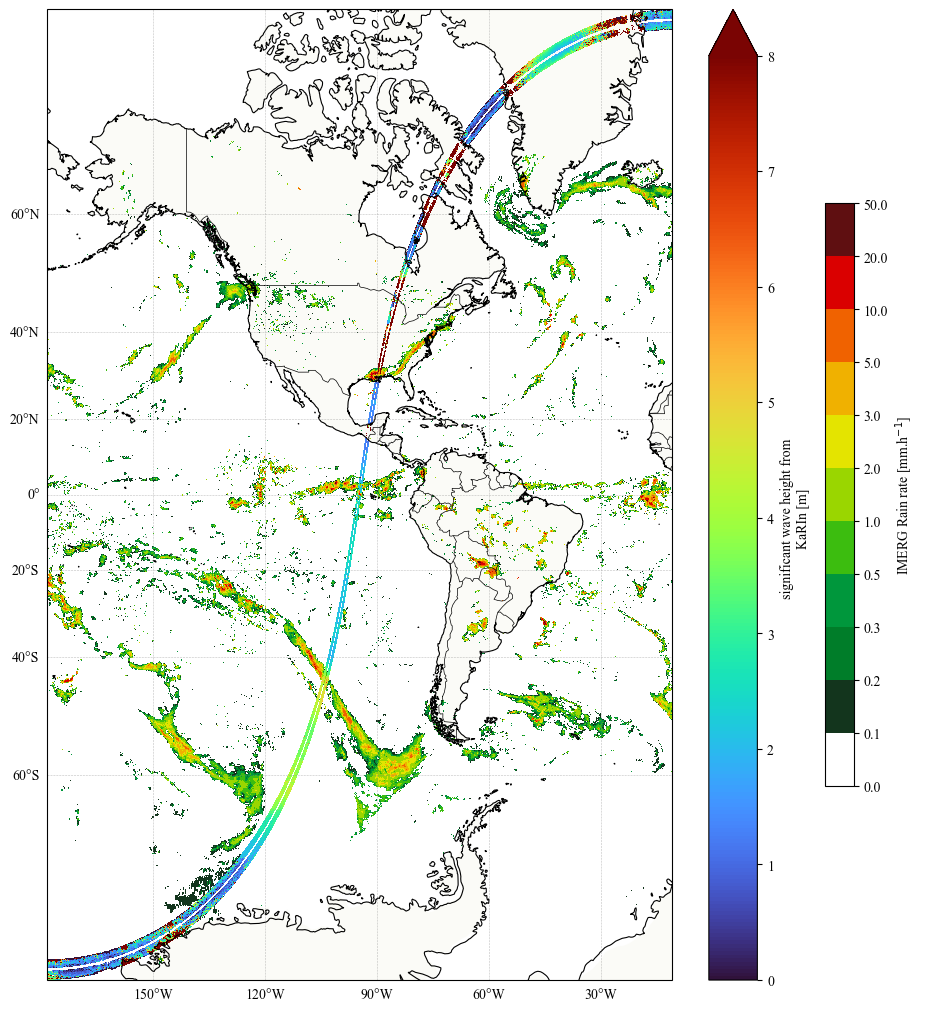

In [11]:
fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot.swh_karin.plot(ax=ax, x="longitude", y="latitude", cmap="turbo", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max], crs=ccrs.PlateCarree())
plt.show()

#### IMERG [mm/h] & KaRIn SWH [m]. Native flags (swh_karin_qual == 0) & (ds_swot.distance_to_coast > 0) applied

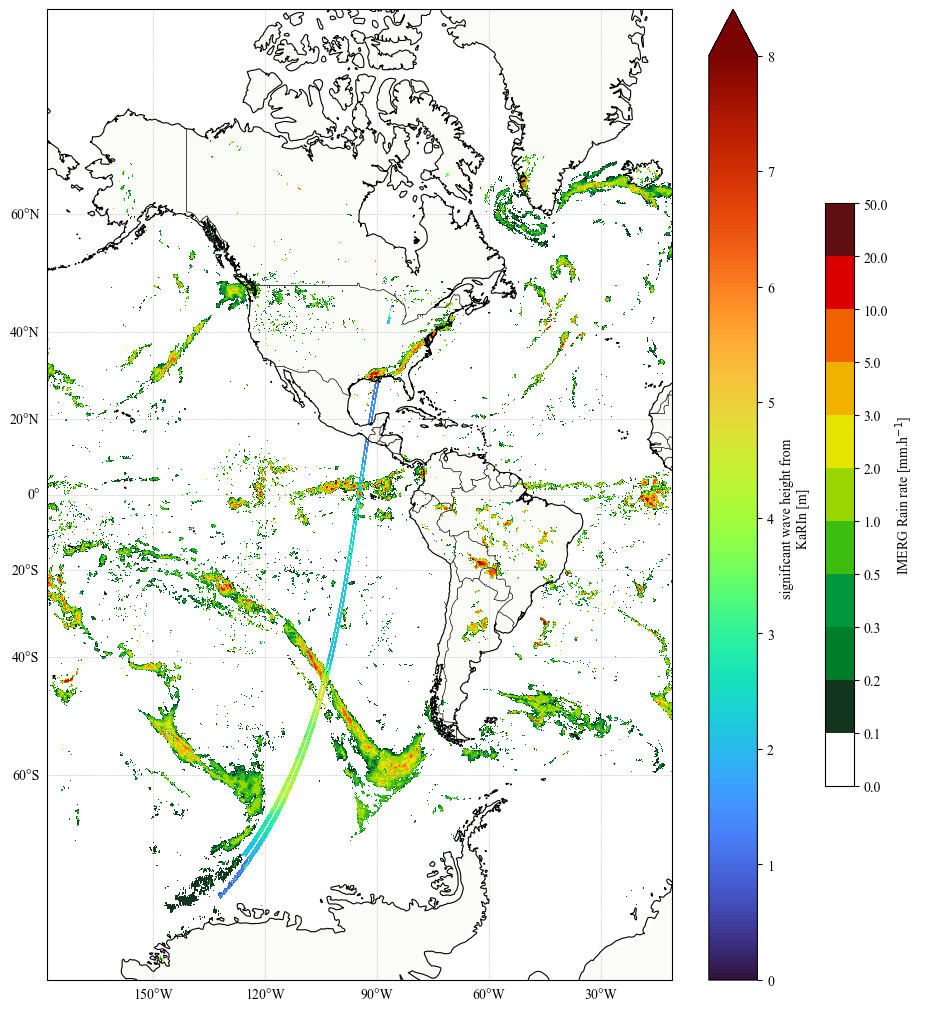

In [12]:
ds_swot_native_filtering = ds_swot.where((ds_swot.swh_karin_qual == 0) & (ds_swot.distance_to_coast > 0))

fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot_native_filtering.swh_karin.plot(ax=ax, x="longitude", y="latitude", cmap="turbo", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max], crs=ccrs.PlateCarree())
plt.show()

#### Zoom on south-east Pacific region

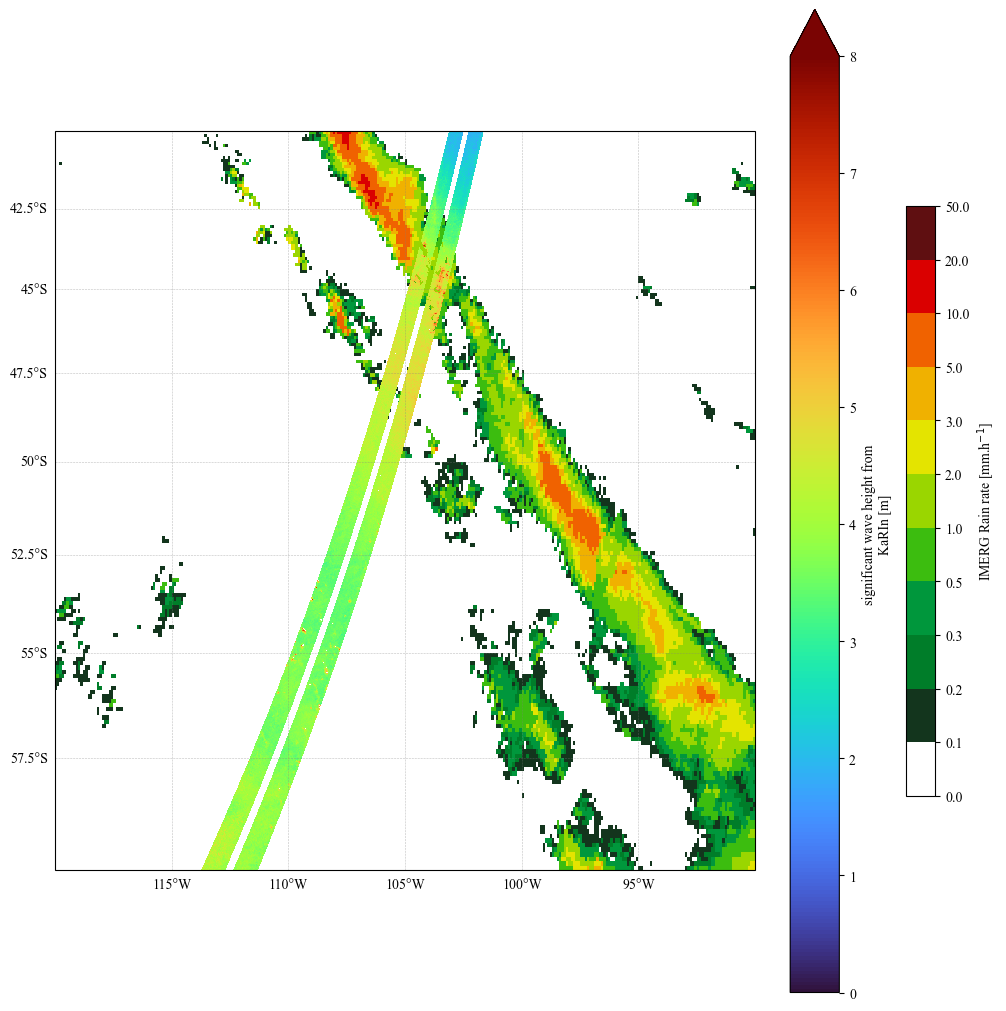

In [13]:
fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot_native_filtering.swh_karin.plot(ax=ax, x="longitude", y="latitude", cmap="turbo", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([-120, -90, -60, -40], crs=ccrs.PlateCarree())
plt.show()

#### Showing SWOT native rain flags (in purple)

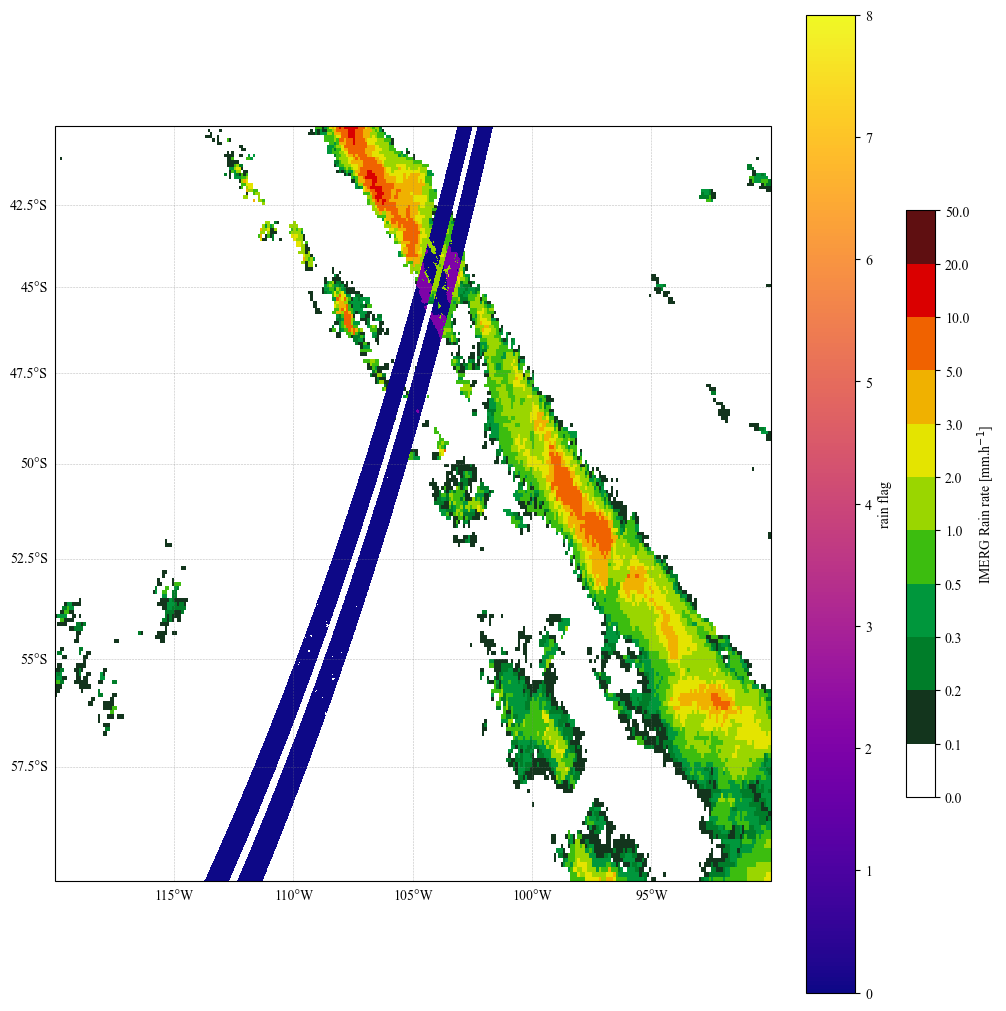

In [14]:
fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot_native_filtering.rain_flag.plot(ax=ax, x="longitude", y="latitude", cmap="plasma", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([-120, -90, -60, -40], crs=ccrs.PlateCarree())
plt.show()

#### Applying SWOT native rain flags

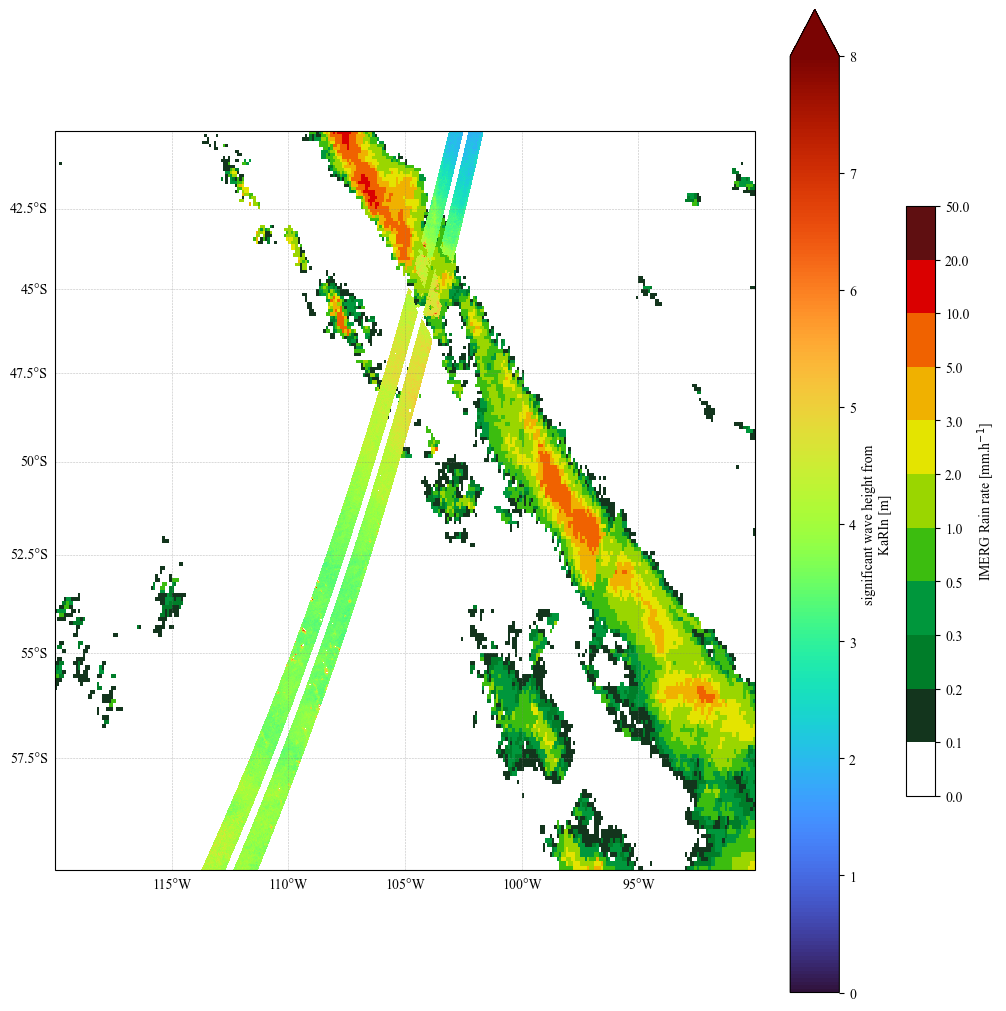

In [15]:
fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot_native_filtering_rain_also = ds_swot_native_filtering.where(ds_swot_native_filtering.rain_flag==0)
ds_swot_native_filtering_rain_also.swh_karin.plot(ax=ax, x="longitude", y="latitude", cmap="turbo", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([-120, -90, -60, -40], crs=ccrs.PlateCarree())
plt.show()

####  IMERG interpolated on SWOT grid

In [16]:
da_regrid = da_imerg.interp(lat=ds_swot.latitude, lon=ds_swot.longitude, method="linear")
ds_imerg_regrid = da_regrid.to_dataset(name="precipitation")

#### BULLDOZER FILTER (LARGE SCALE FILTER)

In [17]:
# == 6. BULLDOZER FILTER =====================================================
ds_swot["IMERG_rain_rate"] = (("num_lines", "num_pixels"), ds_imerg_regrid.precipitation.data)
ds_swot["bulldozer_mask"] = (("num_lines", "num_pixels"), (ds_imerg_regrid.precipitation.data > 0.1).astype(int))

# Description: flag == 0 <==> good data
#              flag == 1 <==> rain contaminated data

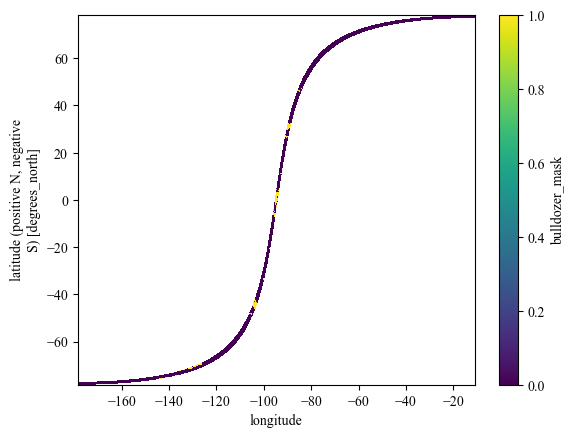

In [18]:
ds_swot.bulldozer_mask.plot(x="longitude", y="latitude")

#### GRADIENT FILTER (FINE SCALE FILTER)

In [19]:
# == 7. GRADIENT FILTER ======================================================   
ds_swot_bulldozered = ds_swot.where(ds_swot.bulldozer_mask == 0)

scale_MAD = 5
try:
    ds_swot_fully_filtered, t_ini_swot_formatted, t_end_swot_formatted = st.format_ds_swot(ds_swot_bulldozered, lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max, untrustable_hs=40, kernel_size_nan=1, step_to_crop_at_edges=0, scale_MAD=scale_MAD, remove_rain=False, window_size=60)
except AttributeError as exc:
    print(f"  [WARN] ATTRIBUTE PROBLEM with {nc_path} : {exc}")
except ValueError as exc:
    print(f"  [WARN] VALUE PROBLEM with {nc_path}: {exc}")

ds_swot["fine_scale_filter_mask"] = (("num_lines", "num_pixels"), ds_swot_fully_filtered.fine_scale_filter.data)

/ontap/user/msimonne/CDD/Projects/Rain/for_ines/matu_scripts/SWOT_tools.py:632: RuntimeWarning: All-NaN slice encountered
  hsmed = np.nanmedian(local_window)
/ontap/user/msimonne/CDD/Projects/Rain/for_ines/matu_scripts/SWOT_tools.py:635: RuntimeWarning: All-NaN slice encountered
  local_mad = np.nanmedian(np.abs(local_window - hsmed))


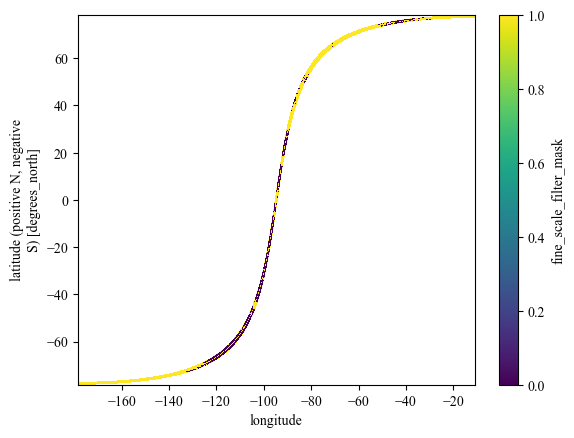

In [20]:
ds_swot.fine_scale_filter_mask.plot(x="longitude", y="latitude")

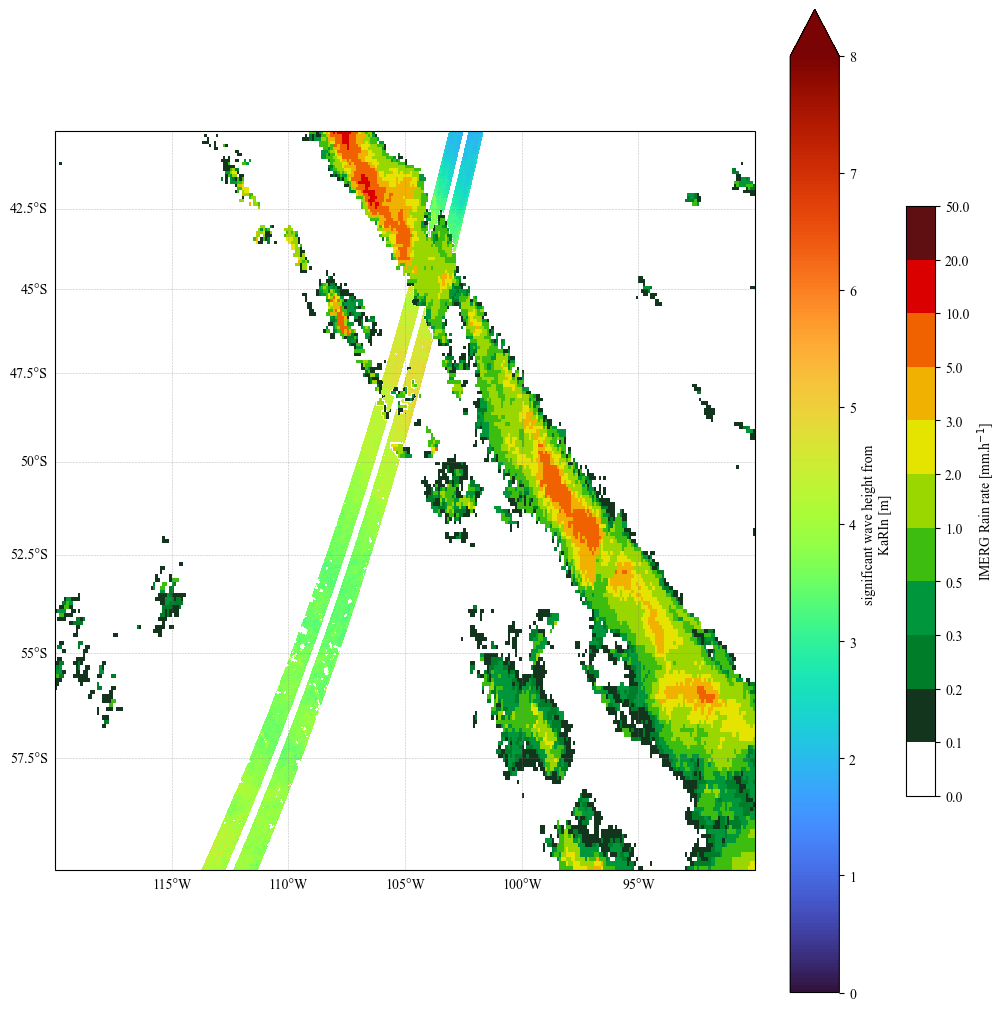

In [21]:
fig, ax = rt.plot_imerg_rain(ds_imerg, shrink=0.6)
ds_swot_fine_scale_filtering = ds_swot.where(ds_swot.fine_scale_filter_mask==0)
ds_swot_fine_scale_filtering.swh_karin.plot(ax=ax, x="longitude", y="latitude", cmap="turbo", vmin=0, vmax=8, transform=ccrs.PlateCarree())
ax.set_extent([-120, -90, -60, -40], crs=ccrs.PlateCarree())
plt.show()

# **III] Applicating the algorithm to the whole dataset**

In [33]:
SWOT_ROOT_INES = "/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0"

swot_files = glob.glob(SWOT_ROOT_INES + "/*")
len(swot_files)

for swot_file in tqdm(swot_files):
    ds_swot = xr.open_dataset(swot_file)
    ds_swot, t_start_str, t_end_str = st.quick_format_ds_swot(ds_swot)
    lon_swot_min, lon_swot_max = np.nanmin(ds_swot.longitude.values), np.nanmax(ds_swot.longitude.values)
    lat_swot_min, lat_swot_max = np.nanmin(ds_swot.latitude.values), np.nanmax(ds_swot.latitude.values)
    area = [lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max]
    print("Area covered by the current SWOT pass:\n", area)
    print(f"Timespan: {t_start_str} --- {t_end_str}")
    t_start, t_end = pd.to_datetime(t_start_str, format="%d/%m/%Y %H:%M:%S").replace(tzinfo=timezone.utc), pd.to_datetime(t_end_str, format="%d/%m/%Y %H:%M:%S").replace(tzinfo=timezone.utc)
    t_mid   = t_start + (t_end - t_start) / 2
    print("t_mid: ", t_mid.strftime(format="%d/%m/%Y %H:%M:%S"))
    
    # == 2. Find closest IMERG granule ==========================================
    f_c = rt.imerg_closest(t_mid)
    print(f_c)
    if f_c is None:
        print("No IMERG file found")
    
    # == 3. Read  IMERG =========================================================
    try:
        p_c, lon_imerg, lat_imerg = rt.read_imerg_precip(f_c, lon_swot_min, lon_swot_max, lat_swot_min, lat_swot_max)
    except Exception as exc:
        print(f"  [WARN] IMERG read {f_c.name}: {exc}")
        #skip_imerg += 1; continue
    
    # == 4. Loading IMERG file as a xarray dataset =======================================
    da_imerg = xr.DataArray(p_c, coords={"lat": lat_imerg, "lon": lon_imerg}, dims=["lat", "lon"])
    ds_imerg = da_imerg.to_dataset(name="precipitation")
    
    # == 5. Interpolate IMERG on SWOT grid =======================================
    da_regrid = da_imerg.interp(lat=ds_swot.latitude, lon=ds_swot.longitude, method="linear")
    ds_imerg_regrid = da_regrid.to_dataset(name="precipitation")
    
    # == 6. BULLDOZER FILTER =====================================================
    ds_swot["IMERG_rain_rate"] = (("num_lines", "num_pixels"), ds_imerg_regrid.precipitation.data)
    ds_swot["bulldozer_mask"] = (("num_lines", "num_pixels"), (ds_imerg_regrid.precipitation.data > 0.1).astype(int))
    
    # Description: flag == 0 <==> good data
    #              flag == 1 <==> rain contaminated data
    
    ds_swot.to_netcdf(swot_file)

  0%|          | 0/2315 [00:00<?, ?it/s]

Area covered by the current SWOT pass:
 [np.float64(-178.481804), np.float64(-11.037271000000032), np.float64(-78.271942), np.float64(78.27206799999999)]
Timespan: 24/03/2025 12:33:23 --- 24/03/2025 13:24:51
t_mid:  24/03/2025 12:59:07
/home/datawork-cersat-project/pimep/data/imerg/gpm_3imerghhl/v7b/2025/083/3B-HHR-L.MS.MRG.3IMERG.20250324-S130000-E132959.0780.V07B.RT-H5


PermissionError: [Errno 13] Permission denied: '/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0/SWOT_L2_LR_SSH_WindWave_030_203_20250324T123323_20250324T132451_PGD0_01.nc'

In [29]:
swot_file

'/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0/SWOT_L2_LR_SSH_WindWave_030_203_20250324T123323_20250324T132451_PGD0_01.nc'

In [30]:
old_ds_swot = xr.open_dataset('/home/datawork-WW3/PROJECT/AMPHITRITE/SWOT/2025/SWOT_L2_KARIN_LR_WindWave_AVISO/PGD0/SWOT_L2_LR_SSH_WindWave_030_203_20250324T123323_20250324T132451_PGD0_01.nc')
for v in old_ds_swot.variables:
    print(v)

time
time_tai
latitude
longitude
polarization_karin
swh_karin
swh_karin_qual
swh_karin_uncert
sig0_karin
sig0_karin_qual
sig0_karin_uncert
sig0_karin_2
sig0_karin_2_qual
wind_speed_karin
wind_speed_karin_qual
wind_speed_karin_2
wind_speed_karin_2_qual
num_pt_avg
swh_wind_speed_karin_source
swh_wind_speed_karin_source_2
swh_nadir_altimeter
swh_model
mean_wave_direction
mean_wave_period_t02
wind_speed_model_u
wind_speed_model_v
wind_speed_rad
distance_to_coast
heading_to_coast
ancillary_surface_classification_flag
dynamic_ice_flag
rain_flag
rad_surface_type_flag


In [23]:
ds_swot.to_netcdf("test_swot.nc")

In [24]:
ds_swot_test = xr.open_dataset("test_swot.nc")

In [28]:
for v in ds_swot_test.variables:
    print(valgorithm)

time
time_tai
polarization_karin
swh_karin
swh_karin_qual
swh_karin_uncert
sig0_karin
sig0_karin_qual
sig0_karin_uncert
sig0_karin_2
sig0_karin_2_qual
wind_speed_karin
wind_speed_karin_qual
wind_speed_karin_2
wind_speed_karin_2_qual
num_pt_avg
swh_wind_speed_karin_source
swh_wind_speed_karin_source_2
swh_nadir_altimeter
swh_model
mean_wave_direction
mean_wave_period_t02
wind_speed_model_u
wind_speed_model_v
wind_speed_rad
distance_to_coast
heading_to_coast
ancillary_surface_classification_flag
dynamic_ice_flag
rain_flag
rad_surface_type_flag
latitude
longitude
IMERG_rain_rate
bulldozer_mask
fine_scale_filter_mask
